<a href="https://colab.research.google.com/github/tinana2k/CS-5530---Tina-Nguyen/blob/main/Assignments/Assignment%202%20%26%203/Q2_Diabetes/src/Q2_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2 - Diabetes Sampling and Bootstrap Analysis

This Colab notebook follows the Q2 assignment requirements.

## Requirements Covered
**(a)** Set a seed, take a random sample of 25 observations, and compare the **mean Glucose** and **highest Glucose** of the sample with the population using charts.

**(b)** Find the **98th percentile of BMI** for the sample and the population and compare them using charts.

**(c)** Using **bootstrap sampling with replacement**, create **500 samples** of size **150** from the population and compute the average **mean**, **standard deviation**, and **98th percentile** for **BloodPressure**. Compare these with the population values using charts and report findings.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [7]:
import pandas as pd
import numpy as np

# Load dataset from your GitHub
url = "https://raw.githubusercontent.com/tinana2k/CS-5530---Tina-Nguyen/main/Assignments/Assignment%202%20%26%203/Q2_Diabetes/data_raw/diabetes.csv"

data = pd.read_csv(url)

print("--- Original Data Loaded ---")
data.info()
display(data.head())

# Summary of Glucose
print("\n--- Summary of Glucose ---")
print(data["Glucose"].describe())

# Check for zero values or missing values in columns that should not be zero
columns_to_impute = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0 with NaN because these values are biologically unrealistic
clean_data = data.copy()
clean_data[columns_to_impute] = clean_data[columns_to_impute].replace(0, np.nan)

print("\n--- Data After Replacing 0 with NaN ---")
display(clean_data.head())

# Calculate median values ignoring NaN
medians = clean_data[columns_to_impute].median()

print("\n--- Median Values Used for Imputation ---")
print(medians)

# Fill NaN values with median
clean_data[columns_to_impute] = clean_data[columns_to_impute].fillna(medians)

# Save cleaned dataset
clean_data.to_csv("clean_data.csv", index=False)

print("\n--- Final Cleaned Data (after imputation) ---")
clean_data.info()
display(clean_data.head())

--- Original Data Loaded ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Summary of Glucose ---
count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

--- Data After Replacing 0 with NaN ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



--- Median Values Used for Imputation ---
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.3
dtype: float64

--- Final Cleaned Data (after imputation) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## **A) Set a seed (to ensure work reproducibility) and take a random sample of 25 observations and find the mean Glucose and highest Glucose values of this sample and compare these statistics with the population statistics of the same variable. You should use charts for this comparison.**

--- Sample of 25 Glucose values ---


,Glucose
766,126.0
748,187.0
42,106.0
485,135.0
543,84.0



--- Summary of Sample Glucose ---
count     25.000000
mean     124.480000
std       32.843213
min       61.000000
25%      106.000000
50%      124.000000
75%      136.000000
max      187.000000
Name: Glucose, dtype: float64

--- Summary of Population Glucose ---
count    768.000000
mean     121.656250
std       30.438286
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

Sample Mean Glucose: 124.48
Sample Max Glucose: 187.0
Population Mean Glucose: 121.66
Population Max Glucose: 199.0

--- A Sample of Mean and Max from Bootstrap ---


,sample_mean_glucose_bs,sample_max_glucose_bs,n
0,120.44,180.0,25
1,123.20,190.0,25
2,112.96,186.0,25
3,123.00,197.0,25
4,118.80,197.0,25



--- Average Mean and Average Max from Bootstrap ---


,avg_mean,avg_max
0,121.27136,185.666


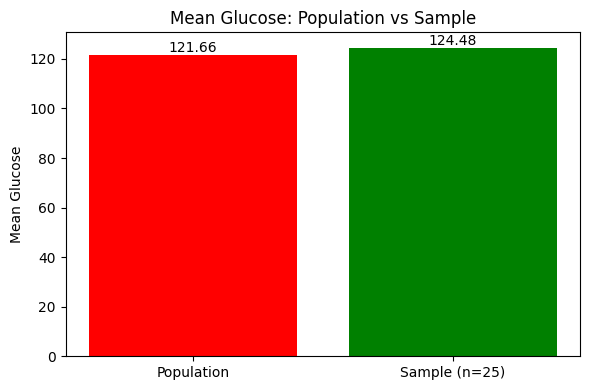

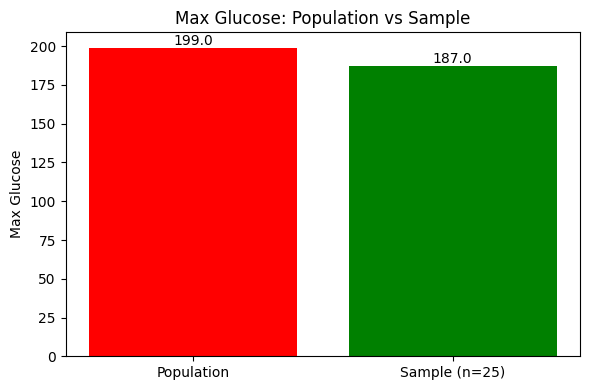

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Q2(a): Random sample of 25 and compare Glucose statistics
# -----------------------------

# Set seed
seed_value = 101
np.random.seed(seed_value)

# Sample size
n = 25

# Select only Glucose column
glu_data = clean_data[["Glucose"]].copy()

# Take random sample of 25 observations (without replacement)
glu_data_25 = glu_data.sample(n=n, random_state=seed_value)

print("--- Sample of 25 Glucose values ---")
display(glu_data_25.head())

print("\n--- Summary of Sample Glucose ---")
print(glu_data_25["Glucose"].describe())

print("\n--- Summary of Population Glucose ---")
print(clean_data["Glucose"].describe())

# Sample summary
sample_mean_glucose = glu_data_25["Glucose"].mean()
sample_max_glucose = glu_data_25["Glucose"].max()

# Population summary
population_mean_glucose = clean_data["Glucose"].mean()
population_max_glucose = clean_data["Glucose"].max()

print("\nSample Mean Glucose:", round(sample_mean_glucose, 2))
print("Sample Max Glucose:", round(sample_max_glucose, 2))
print("Population Mean Glucose:", round(population_mean_glucose, 2))
print("Population Max Glucose:", round(population_max_glucose, 2))

# -----------------------------
# Bootstrap with 500 samples of size 25
# -----------------------------
num_trials = 500

bootstrap_results = []

for i in range(num_trials):
    boot_sample = clean_data.sample(n=n, replace=True, random_state=seed_value + i)
    bootstrap_results.append({
        "sample_mean_glucose_bs": boot_sample["Glucose"].mean(),
        "sample_max_glucose_bs": boot_sample["Glucose"].max(),
        "n": n
    })

glu_data_25_means_maxs = pd.DataFrame(bootstrap_results)

print("\n--- A Sample of Mean and Max from Bootstrap ---")
display(glu_data_25_means_maxs.head())

avg_glu_data_25_means_maxs = pd.DataFrame({
    "avg_mean": [glu_data_25_means_maxs["sample_mean_glucose_bs"].mean()],
    "avg_max": [glu_data_25_means_maxs["sample_max_glucose_bs"].mean()]
})

print("\n--- Average Mean and Average Max from Bootstrap ---")
display(avg_glu_data_25_means_maxs)

# -----------------------------
# Chart 1: Mean Glucose comparison without bootstrap
# -----------------------------
mean_data_df = pd.DataFrame({
    "Category": ["Population", "Sample (n=25)"],
    "MeanGlucose": [population_mean_glucose, sample_mean_glucose]
})

plt.figure(figsize=(6, 4))

colors = ["red", "green"]  # Population, Sample

bars = plt.bar(
    mean_data_df["Category"],
    mean_data_df["MeanGlucose"],
    color=colors
)

plt.title("Mean Glucose: Population vs Sample")
plt.ylabel("Mean Glucose")

# Add labels on top
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

# -----------------------------
# Chart 2: Max Glucose comparison without bootstrap
# -----------------------------
max_data_df = pd.DataFrame({
    "Category": ["Population", "Sample (n=25)"],
    "MaxGlucose": [population_max_glucose, sample_max_glucose]
})

plt.figure(figsize=(6, 4))

colors = ["red", "green"]

bars = plt.bar(
    max_data_df["Category"],
    max_data_df["MaxGlucose"],
    color=colors
)

plt.title("Max Glucose: Population vs Sample")
plt.ylabel("Max Glucose")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 0),
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

## **B) Find the 98th percentile of BMI of your sample and the population and compare the results using charts.**

Sample 98th Percentile BMI: 53.02
Population 98th Percentile BMI: 47.53


,Category,BMIQ98
0,Population,47.526
1,Sample (n=25),53.016


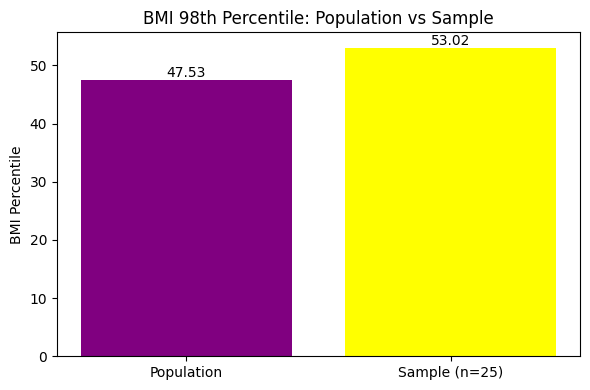

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Q2(b): 98th percentile of BMI
# -----------------------------

# Set seed
seed_value = 101
np.random.seed(seed_value)

# Make sure n is defined
n = 25

# Select BMI column
bmi_data = clean_data[["BMI"]].copy()

# Take random sample of 25 observations
bmi_data_25 = bmi_data.sample(n=n, random_state=seed_value)

# Compute 98th percentile
sample_bmi_q98 = np.percentile(bmi_data_25["BMI"], 98)
population_bmi_q98 = np.percentile(bmi_data["BMI"], 98)

print("Sample 98th Percentile BMI:", round(sample_bmi_q98, 2))
print("Population 98th Percentile BMI:", round(population_bmi_q98, 2))

# Create comparison table
bmi_data_df = pd.DataFrame({
    "Category": ["Population", "Sample (n=25)"],
    "BMIQ98": [population_bmi_q98, sample_bmi_q98]
})

display(bmi_data_df)

# -----------------------------
# Chart: BMI Q98 comparison
# -----------------------------
plt.figure(figsize=(6, 4))

colors = ["purple", "yellow"]

bars = plt.bar(
    bmi_data_df["Category"],
    bmi_data_df["BMIQ98"],
    color=colors
)

plt.title("BMI 98th Percentile: Population vs Sample")
plt.ylabel("BMI Percentile")

# Add labels on top
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        round(y, 2),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## **C) Using bootstrap (replace= True), create 500 samples (of 150 observation each) from the population and find the average mean, standard deviation and percentile for BloodPressure and compare this with these statistics from the population for the same variable. Again, you should create charts for this comparison**.

### **1. BloodPressure Statistics between Sample and Population**

In [17]:
import pandas as pd
import numpy as np

# -----------------------------
# Q2(c): Bootstrap for BloodPressure
# -----------------------------

# Set seed
seed_value = 101
np.random.seed(seed_value)

# Number of bootstrap trials
numb_trials = 500

# Sample size for each bootstrap sample
sample_size = 150

# Select BloodPressure column from clean_data
bloodpressure_data = clean_data[["BloodPressure"]].copy()

# Example one bootstrap sample of size 150
bloodpressure_data_150 = clean_data.sample(
    n=sample_size,
    replace=True,
    random_state=seed_value
)[["BloodPressure"]]

print("--- Population BloodPressure Summary ---")
print(bloodpressure_data["BloodPressure"].describe())

print("\n--- Example Bootstrap Sample (n=150) ---")
display(bloodpressure_data_150.head())

# -----------------------------------
# Create 500 bootstrap samples
# -----------------------------------
bootstrap_results = []

for i in range(numb_trials):
    boot_sample = clean_data.sample(
        n=sample_size,
        replace=True,
        random_state=seed_value + i
    )["BloodPressure"]

    bootstrap_results.append({
        "mean": boot_sample.mean(),
        "sd": boot_sample.std(),
        "p0": np.percentile(boot_sample, 0),
        "p25": np.percentile(boot_sample, 25),
        "p50": np.percentile(boot_sample, 50),
        "p75": np.percentile(boot_sample, 75),
        "p100": np.percentile(boot_sample, 100),
        "n": sample_size
    })

bloodpressure_150_data = pd.DataFrame(bootstrap_results)

print("\n--- Sample of Bootstrap Results ---")
display(bloodpressure_150_data.head())

# -----------------------------------
# Calculate average summary statistics
# -----------------------------------
avg_sample = pd.DataFrame({
    "avg_mean": [bloodpressure_150_data["mean"].mean()],
    "avg_std": [bloodpressure_150_data["sd"].mean()],
    "avg_p0": [bloodpressure_150_data["p0"].mean()],
    "avg_p25": [bloodpressure_150_data["p25"].mean()],
    "avg_p50": [bloodpressure_150_data["p50"].mean()],
    "avg_p75": [bloodpressure_150_data["p75"].mean()],
    "avg_p100": [bloodpressure_150_data["p100"].mean()]
})

print("\n--- Average of Bootstrap Sample Distribution ---")
display(avg_sample)

# Convert to long format like pivot_longer in R
avg_sample_long = avg_sample.melt(
    var_name="Statistic",
    value_name="Value"
)

avg_sample_long["Value"] = avg_sample_long["Value"].round(2)

print("\n--- Long Format Average Summary ---")
display(avg_sample_long)

--- Population BloodPressure Summary ---
count    768.000000
mean      72.386719
std       12.096642
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

--- Example Bootstrap Sample (n=150) ---


,BloodPressure
523,70.0
337,76.0
575,44.0
599,38.0
75,48.0



--- Sample of Bootstrap Results ---


,mean,sd,p0,p25,p50,p75,p100,n
0,71.993333,11.347173,38.0,66.00,72.0,78.0,108.0,150
1,72.933333,13.567958,30.0,64.00,72.0,82.0,114.0,150
2,73.173333,11.982508,44.0,64.25,72.0,81.5,110.0,150
3,72.846667,13.000122,30.0,66.00,72.0,81.5,110.0,150
4,73.346667,11.880833,44.0,64.00,74.0,82.0,102.0,150



--- Average of Bootstrap Sample Distribution ---


,avg_mean,avg_std,avg_p0,avg_p25,avg_p50,avg_p75,avg_p100
0,72.42192,12.089255,36.164,64.622,72.115,79.538,110.436



--- Long Format Average Summary ---


,Statistic,Value
0,avg_mean,72.42
1,avg_std,12.09
2,avg_p0,36.16
3,avg_p25,64.62
4,avg_p50,72.11
5,avg_p75,79.54
6,avg_p100,110.44


### **2. Create a comparison charts between sample and population**

,Statistic,Type,Value
0,Mean,Population,72.386719
1,Std. Deviation,Population,12.096642
2,0th Pct,Population,24.000000
3,25th Pct,Population,64.000000
4,50th Pct,Population,72.000000
5,75th Pct,Population,80.000000
6,100th Pct,Population,122.000000
7,Mean,Avg. Sample,72.421920
8,Std. Deviation,Avg. Sample,12.089255
9,0th Pct,Avg. Sample,36.164000


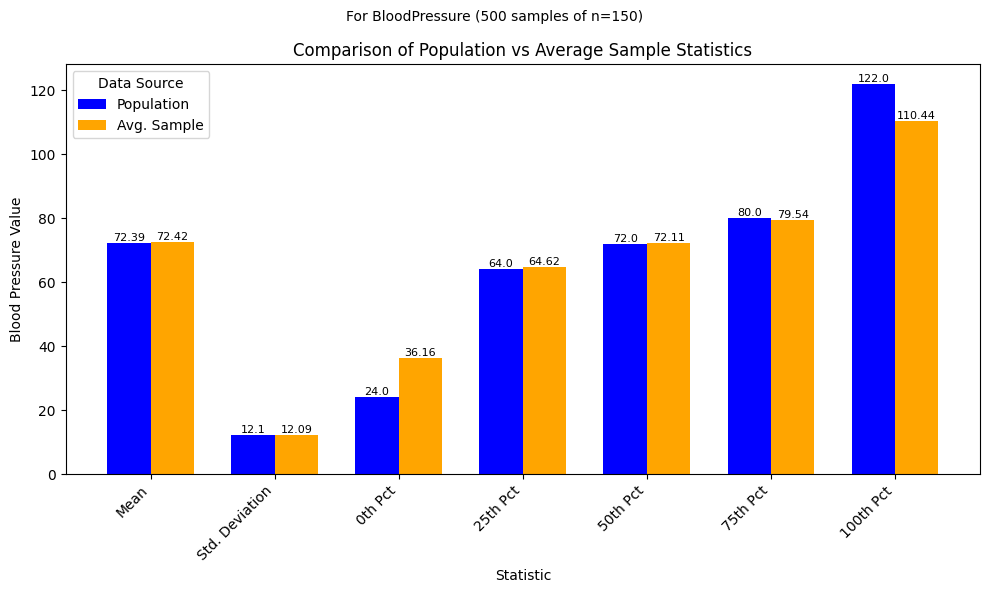

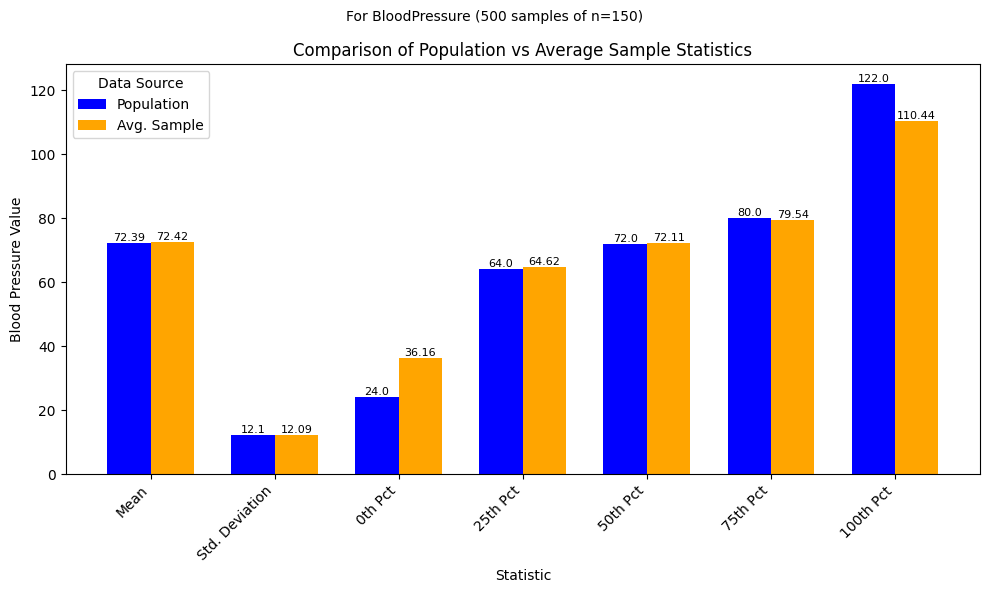

✅ Plot saved to: /content/results/comparison_plot.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1. Population summary
# -----------------------------
avg_pop = {
    "Mean": bloodpressure_data["BloodPressure"].mean(),
    "Std. Deviation": bloodpressure_data["BloodPressure"].std(),
    "0th Pct": np.percentile(bloodpressure_data["BloodPressure"], 0),
    "25th Pct": np.percentile(bloodpressure_data["BloodPressure"], 25),
    "50th Pct": np.percentile(bloodpressure_data["BloodPressure"], 50),
    "75th Pct": np.percentile(bloodpressure_data["BloodPressure"], 75),
    "100th Pct": np.percentile(bloodpressure_data["BloodPressure"], 100)
}

# -----------------------------
# 2. Average bootstrap summary
# -----------------------------
avg_sample_dict = {
    "Mean": bloodpressure_150_data["mean"].mean(),
    "Std. Deviation": bloodpressure_150_data["sd"].mean(),
    "0th Pct": bloodpressure_150_data["p0"].mean(),
    "25th Pct": bloodpressure_150_data["p25"].mean(),
    "50th Pct": bloodpressure_150_data["p50"].mean(),
    "75th Pct": bloodpressure_150_data["p75"].mean(),
    "100th Pct": bloodpressure_150_data["p100"].mean()
}

# -----------------------------
# 3. Create plotting dataframe
# -----------------------------
plot_data = pd.DataFrame({
    "Statistic": list(avg_pop.keys()) + list(avg_sample_dict.keys()),
    "Type": ["Population"] * 7 + ["Avg. Sample"] * 7,
    "Value": list(avg_pop.values()) + list(avg_sample_dict.values())
})

display(plot_data)

# -----------------------------
# 4. Create grouped bar chart
# -----------------------------
statistics = list(avg_pop.keys())
x = np.arange(len(statistics))
width = 0.35

population_values = [avg_pop[s] for s in statistics]
sample_values = [avg_sample_dict[s] for s in statistics]

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, population_values, width, label="Population", color="blue")
bars2 = plt.bar(x + width/2, sample_values, width, label="Avg. Sample", color="orange")

# Add labels on top
for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom", fontsize=8)

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom", fontsize=8)

plt.title("Comparison of Population vs Average Sample Statistics")
plt.suptitle("For BloodPressure (500 samples of n=150)", y=0.98, fontsize=10)
plt.xlabel("Statistic")
plt.ylabel("Blood Pressure Value")
plt.xticks(x, statistics, rotation=45, ha="right")
plt.legend(title="Data Source")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Save the plot
# -----------------------------
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, population_values, width, label="Population", color="blue")
bars2 = plt.bar(x + width/2, sample_values, width, label="Avg. Sample", color="orange")

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom", fontsize=8)

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom", fontsize=8)

plt.title("Comparison of Population vs Average Sample Statistics")
plt.suptitle("For BloodPressure (500 samples of n=150)", y=0.98, fontsize=10)
plt.xlabel("Statistic")
plt.ylabel("Blood Pressure Value")
plt.xticks(x, statistics, rotation=45, ha="right")
plt.legend(title="Data Source")
plt.tight_layout()

save_path = results_dir / "comparison_plot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Plot saved to:", save_path.resolve())

# **Save results**

In [19]:
from google.colab import files

files.download("results/comparison_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from pathlib import Path
from google.colab import files

Path("data_clean").mkdir(exist_ok=True)

clean_data.to_csv("data_clean/clean_data.csv", index=False)

files.download("data_clean/clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

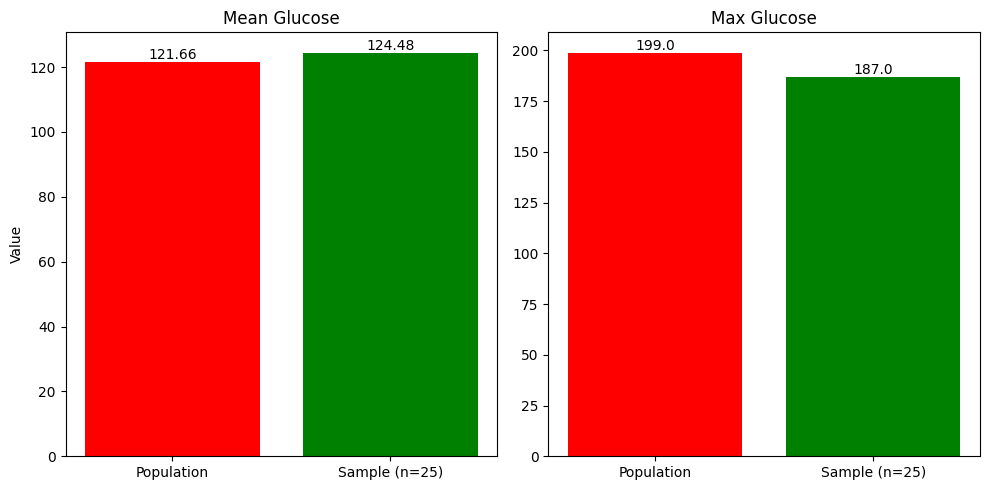

✅ Saved to: results/glucose_mean_max.png


In [24]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create results folder
Path("results").mkdir(parents=True, exist_ok=True)

# Data (make sure these already exist)
# population_mean_glucose
# sample_mean_glucose
# population_max_glucose
# sample_max_glucose

# Prepare data
mean_data = [population_mean_glucose, sample_mean_glucose]
max_data = [population_max_glucose, sample_max_glucose]
categories = ["Population", "Sample (n=25)"]

# Create figure
plt.figure(figsize=(10, 5))

# Plot Mean
plt.subplot(1, 2, 1)
bars = plt.bar(categories, mean_data, color=["red", "green"])
plt.title("Mean Glucose")
plt.ylabel("Value")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 2),
             ha="center", va="bottom")

# Plot Max
plt.subplot(1, 2, 2)
bars = plt.bar(categories, max_data, color=["red", "green"])
plt.title("Max Glucose")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, round(y, 0),
             ha="center", va="bottom")

plt.tight_layout()

# Save PNG
save_path = "results/glucose_mean_max.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("✅ Saved to:", save_path)

In [25]:
from google.colab import files

files.download("results/glucose_mean_max.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

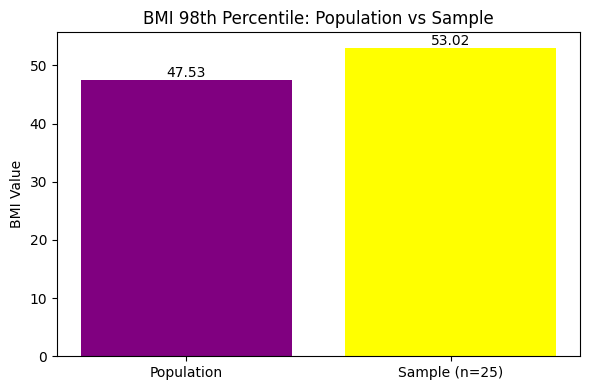

✅ Saved to: results/bmi_98th_percentile.png


In [26]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create results folder
Path("results").mkdir(parents=True, exist_ok=True)

# Data (make sure these exist)
# sample_bmi_q98
# population_bmi_q98

categories = ["Population", "Sample (n=25)"]
values = [population_bmi_q98, sample_bmi_q98]

plt.figure(figsize=(6, 4))

bars = plt.bar(categories, values, color=["purple", "yellow"])

plt.title("BMI 98th Percentile: Population vs Sample")
plt.ylabel("BMI Value")

# Add labels on top
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        round(y, 2),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save PNG
save_path = "results/bmi_98th_percentile.png"
plt.savefig(save_path, dpi=300)

plt.show()

print("✅ Saved to:", save_path)

In [27]:
from google.colab import files

files.download("results/bmi_98th_percentile.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>